# Problem 1: Measuring butterflies
To discover things about a butterfly population, the Natural History Museum has measured the width of several butterflies in its collection.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

wing_widths = [7.02, 6.84, 6.56, 6.44, 0.0, 0.0, 4.92, 6.35, 6.07, 6.68, 6.91, 7.09, 8.90, 0.0,
               9.79, 6.32, 7.24, 7.27, 8.02, 0.0, 7.76, 6.94, 5.80, 7.43, 6.85, 8.44, 5.16, 7.96,
               0.0, 6.99, 8.56, 5.20, 5.76, 6.87, 6.41, 0.0, 7.36, 5.74, 7.06, 6.44, 8.06, 7.86]

* Find the __mean width__ of the wings, the __median__, __standard deviation__
* Find the width of the largest wing and the smallest

In [2]:
arr = np.array(wing_widths)

mean_width = np.mean(arr)
median_width = np.median(arr)
std_dev = np.std(arr)
max_width = np.max(arr)
min_width = np.min(arr)

print(f"Mean: {mean_width:.2f}")
print(f"Median: {median_width:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Largest Wing: {max_width:.2f}")
print(f"Smallest Wing: {min_width:.2f}")

Mean: 5.98
Median: 6.84
Standard Deviation: 2.63
Largest Wing: 9.79
Smallest Wing: 0.00


* Now plot a histogram of the data
* Try adjusting the number of bins in the histogram to have a better representation

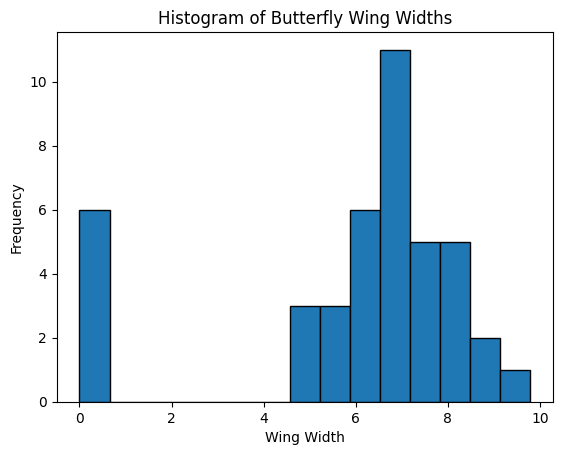

In [7]:
plt.hist(wing_widths, bins=15, edgecolor='black')
plt.xlabel('Wing Width')
plt.ylabel('Frequency')
plt.title('Histogram of Butterfly Wing Widths')
plt.show()

* Count how many wings have been given a wing width of zero
* Now find the new mean, median and min and max of the elements different from zero
* Plot a histogram of this data



In [4]:
# 값이 0인 나비 날개 개수 세기
zero_count = wing_widths.count(0.0)
print("0인 데이터 개수:", zero_count)

# 0을 제외한 데이터 필터링 및 통계량 계산
filtered_widths = [w for w in wing_widths if w > 0.0]

new_mean = np.mean(filtered_widths)
new_median = np.median(filtered_widths)
new_min = np.min(filtered_widths)
new_max = np.max(filtered_widths)

print(f"새로운 평균: {new_mean:.2f}")
print(f"새로운 중앙값: {new_median:.2f}")
print(f"새로운 최솟값: {new_min:.2f}")
print(f"새로운 최댓값: {new_max:.2f}")

0인 데이터 개수: 6
새로운 평균: 6.97
새로운 중앙값: 6.93
새로운 최솟값: 4.92
새로운 최댓값: 9.79


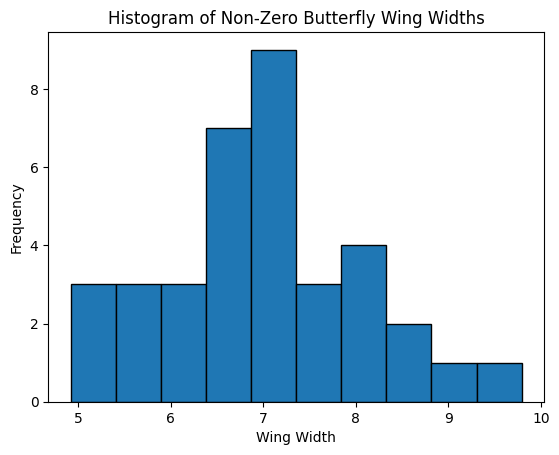

In [5]:
# 히스토그램 그리기
plt.hist(filtered_widths, bins=10, edgecolor='black')
plt.xlabel('Wing Width')
plt.ylabel('Frequency')
plt.title('Histogram of Non-Zero Butterfly Wing Widths')
plt.show()

**Additional**

* Plot a vertical line, where the mean is
* Plot a vertical line, where the smallest & largest  values are


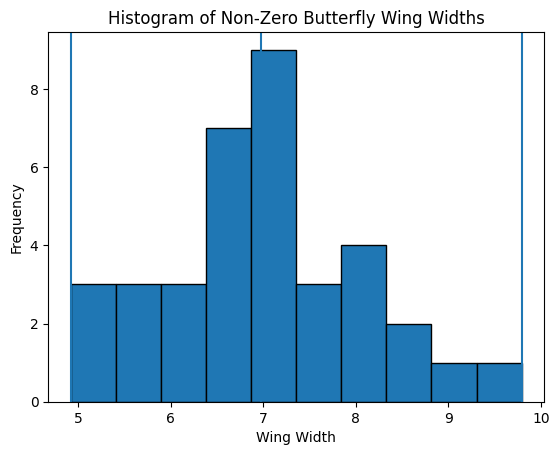

In [9]:
plt.hist(filtered_widths, bins=10, edgecolor='black')
plt.xlabel('Wing Width')
plt.ylabel('Frequency')
plt.title('Histogram of Non-Zero Butterfly Wing Widths')

# 평균, 최솟값, 최댓값 위치에 수직선 추가
plt.axvline(new_mean)
plt.axvline(new_min)
plt.axvline(new_max)

plt.show()

# Problem 2: Plotting parabolas
Write Python code that produces the following figure:

![alt text](http://www.cs.ucl.ac.uk/scipython/img/a4_parabolas.png "Parabolas")

/tmp/ipykernel_894/2374705733.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x, y2, 'k--', color='#444444', label=r'$f(x)=5x^2+3$') # 검은색 점선


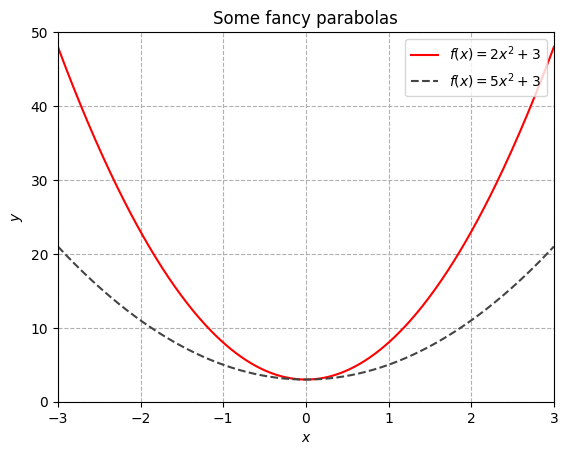

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# x 값 범위 설정 (-3부터 3까지)
x = np.linspace(-3, 3, 400)

# 두 이차함수 정의
y1 = 5 * x**2 + 3
y2 = 2 * x**2 + 3

# 그래프 그리기
plt.plot(x, y1, 'r-', label=r'$f(x)=2x^2+3$')      # 빨간색 실선
plt.plot(x, y2, 'k--', color='#444444', label=r'$f(x)=5x^2+3$') # 검은색 점선

# 축 범위 및 라벨 설정
plt.xlim(-3, 3)
plt.ylim(0, 50)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Some fancy parabolas')

# 격자 및 범례 추가
plt.grid(True, linestyle='--')
plt.legend(loc='upper right')

plt.show()

# Problem 2: Healthy Breakfast
In this exercise we will do some simple analyses on a data set that contains information about 77 types of breakfast cereal. You can read about the data set at [CMU's website](http://lib.stat.cmu.edu/DASL/Stories/HealthyBreakfast.html). Download the files [cereal.csv](http://www.cs.ucl.ac.uk/scipython/resources/cereal.txt) from the course website. Below you can find a small code snippet to get you started on  reading the data set from the file.

In [11]:
%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


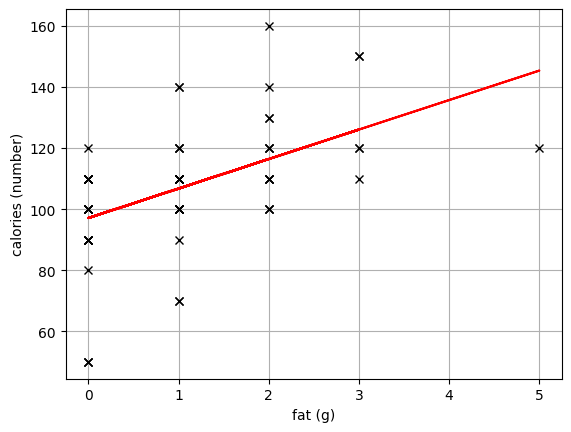

In [12]:
def getData(filename = 'cereal.txt'):
    """
    지정한 파일명에서 시리얼 데이터를 읽어옵니다.
    열 라벨, 제품 이름 목록, 속성 데이터 배열을 튜플로 반환합니다.
    """
    names = []
    data = []
    col_labels = ["calories (number)", "protein (g)", "fat (g)", "sodium (mg)",
                  "dietary fiber (g)", "complex carbohydrates (g)", "sugars (g)",
                  "display shelf (1, 2, or 3, counting from the floor)", "potassium (mg)",
                  "vitamins and minerals (0, 25, or 100, respectively)",
                  "weight (in ounces) of one serving (serving size)", "cups per serving"]

    with open(filename) as f:
        for l in f:
          fields = l.split()
          names.append(fields[0])
          data.append([float(x) for x in fields[3:]])

    data = np.array(data)
    return col_labels, names, data

def plotFatVsCalories(col_labels, data):
    """
    지방 함량 대비 칼로리를 산점도로 시각화합니다.
    """

    fat = data[:,2]
    calories = data[:,0]
    plt.plot(fat, calories ,'kx')
    plt.xlabel(col_labels[2])
    plt.ylabel(col_labels[0])
    plt.grid()

    # 점들을 지나는 직선을 적합시키기
    coefficients = np.polyfit(fat, calories, 1)
    poly = np.poly1d(coefficients)
    plt.plot(fat, poly(fat), 'r-')

# 함수 실행
file_path = "/content/drive/MyDrive/2026-2학기 대학원 신입생 과제/cereal.txt"
column_labels, productNames, data = getData(file_path)
plotFatVsCalories(column_labels, data)

Please complete the following tasks:

> **1.** Compute the average number of calories, as well as the average amount of complex carbohydrates and sugars in the data set.

In [13]:
# 라벨 목록에서 각 항목의 인덱스 찾기
cal_idx = column_labels.index("calories (number)")
carbs_idx = column_labels.index("complex carbohydrates (g)")
sugars_idx = column_labels.index("sugars (g)")

# 인덱스 출력
print(f"Calories Index: {cal_idx}")
print(f"Complex Carbohydrates Index: {carbs_idx}")
print(f"Sugars Index: {sugars_idx}")

Calories Index: 0
Complex Carbohydrates Index: 5
Sugars Index: 6


In [14]:
# 찾은 인덱스를 활용한 평균값 계산
avg_calories = np.mean(data[:, cal_idx])
avg_carbs = np.mean(data[:, carbs_idx])
avg_sugars = np.mean(data[:, sugars_idx])

print(f"\nAverage Calories: {avg_calories:.2f}")
print(f"Average Complex Carbohydrates: {avg_carbs:.2f} g")
print(f"Average Sugars: {avg_sugars:.2f} g")


Average Calories: 106.88
Average Complex Carbohydrates: 14.60 g
Average Sugars: 6.92 g


> **2.** What is the name of the cereal that has the highest sugar content?

In [15]:
# 당류 항목의 인덱스 찾기
sugars_idx = column_labels.index("sugars (g)")

# 가장 높은 당 함량을 가진 시리얼의 인덱스 계산
max_sugar_idx = np.argmax(data[:, sugars_idx])

# 시리얼 이름 및 당 함량 출력
highest_sugar_cereal = productNames[max_sugar_idx]
max_sugar_value = data[max_sugar_idx, sugars_idx]

print(f"Highest Sugar Cereal: {highest_sugar_cereal} ({max_sugar_value} g)")

Highest Sugar Cereal: Golden_Crisp (15.0 g)


> **3.** The 8th column of the data set contains the shelf at which the cereal is displayed in the supermarket (either 1, 2, or 3). Compute the mean number of calories of the cereals displayed in each shelf. If you do this correctly you should find the the cereals displayed on the middle shelf have a higher calory content on average.

In [16]:
# 진열대 인덱스 및 칼로리 인덱스 찾기
shelf_idx = column_labels.index("display shelf (1, 2, or 3, counting from the floor)")
cal_idx = column_labels.index("calories (number)")

# 각 진열대별 평균 칼로리 계산
shelf_1_calories = np.mean(data[data[:, shelf_idx] == 1, cal_idx])
shelf_2_calories = np.mean(data[data[:, shelf_idx] == 2, cal_idx])
shelf_3_calories = np.mean(data[data[:, shelf_idx] == 3, cal_idx])

print(f"Shelf 1 평균 칼로리: {shelf_1_calories:.2f}")
print(f"Shelf 2 평균 칼로리: {shelf_2_calories:.2f}")
print(f"Shelf 3 평균 칼로리: {shelf_3_calories:.2f}")

Shelf 1 평균 칼로리: 102.50
Shelf 2 평균 칼로리: 109.52
Shelf 3 평균 칼로리: 107.78


> **4.** Make a box plot showing the sugar content of cereals grouped by shelf (recreating the plot that you'll find on the homepage for this data set).

/tmp/ipykernel_894/2362457142.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([shelf1_sugars, shelf2_sugars, shelf3_sugars], labels=['1', '2', '3'])


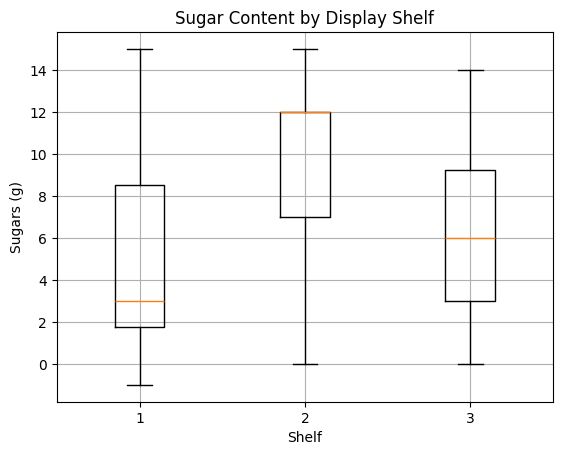

In [17]:
# 각 진열대별 당류 데이터 추출
shelf1_sugars = data[data[:, shelf_idx] == 1, sugars_idx]
shelf2_sugars = data[data[:, shelf_idx] == 2, sugars_idx]
shelf3_sugars = data[data[:, shelf_idx] == 3, sugars_idx]

# Box plot 그리기
plt.boxplot([shelf1_sugars, shelf2_sugars, shelf3_sugars], labels=['1', '2', '3'])
plt.xlabel('Shelf')
plt.ylabel('Sugars (g)')
plt.title('Sugar Content by Display Shelf')
plt.grid(True)
plt.show()

> **5.** Explore the data set by plotting and regressing the different variables against each other.

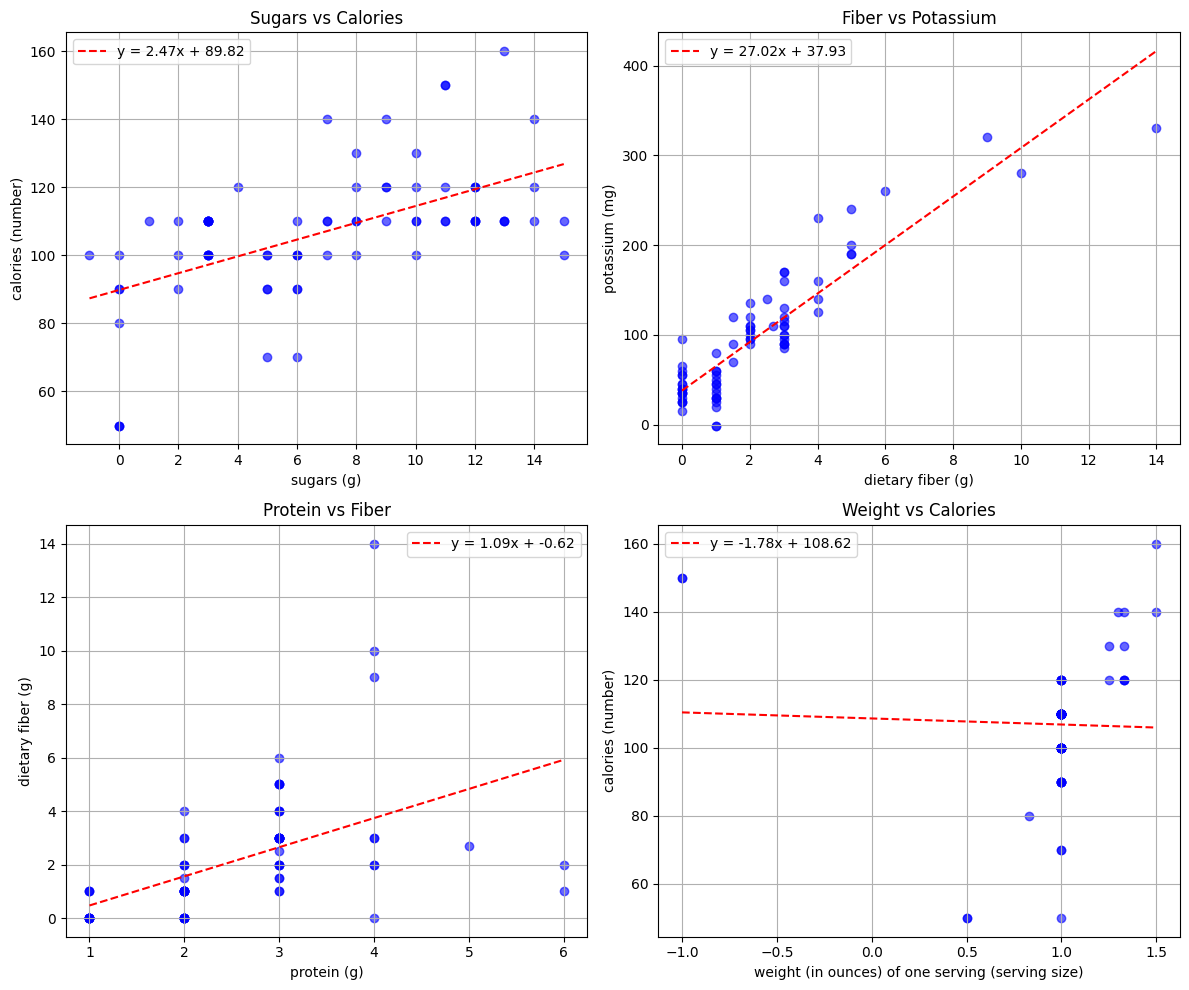

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 탐색할 변수 쌍 지정: (x_index, y_index, 제목)
pairs = [
    (6, 0, 'Sugars vs Calories'),
    (4, 8, 'Fiber vs Potassium'),
    (1, 4, 'Protein vs Fiber'),
    (10, 0, 'Weight vs Calories')
]

for ax, (x_idx, y_idx, title) in zip(axes.flat, pairs):
    x = data[:, x_idx]
    y = data[:, y_idx]

    # 산점도 그리기
    ax.scatter(x, y, color='blue', alpha=0.6)
    ax.set_xlabel(column_labels[x_idx])
    ax.set_ylabel(column_labels[y_idx])
    ax.set_title(title)
    ax.grid(True)

    # 선형 회귀선 적합 및 그리기
    coefs = np.polyfit(x, y, 1)
    poly = np.poly1d(coefs)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, poly(x_line), 'r--', label=f'y = {coefs[0]:.2f}x + {coefs[1]:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Problem 3: Chocolate makes you faster?
Your colleague (a psychologist) has conducted an experiment where he measured subjects' performance on a memory and a reaction time task. He claims to have found a correlation between the two, but you are sceptical, because you know your colleague is not very good at clicking buttons in SPSS. Luckily, you can convince your colleague to give you his data file so you can assess his claims.

> **1.** He gives you the file [experiment.csv](http://www.cs.ucl.ac.uk/scipython/resources/experiment.csv). It contains one line per subject, and each line contains the values for the following variables that he measured: `height`, `weight`, `amount-chocolate`, `task-one-score`, `task-two-score`. (He allowed the participants to eat chocolate during the experiment, and the third column shows the amount of chocolate they ate in grams.) Load the data into an array.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
data = np.loadtxt('/content/drive/MyDrive/2026-2학기 대학원 신입생 과제/experiment.csv')
print(data[:5])

[[ 1.72626685e+00  6.82590088e+01  9.00000000e+01  6.90595628e+00
   1.59161416e+00]
 [ 1.70859173e+00  7.59079695e+01  1.10000000e+02  3.30912833e+00
  -1.27713299e+01]
 [ 1.79406497e+00  7.28120605e+01  1.40000000e+02 -1.57342990e+01
  -2.29336897e+01]
 [ 1.68850538e+00  7.81816836e+01  1.10000000e+02 -3.34179176e+00
  -6.31385031e-02]
 [ 1.75958935e+00  7.07166454e+01  8.00000000e+01  1.39231381e+01
   1.29479312e+00]]


> **2.** As a sanity check, create a scatter plot of height vs. weight. These two should clearly be correlated and you should see a straight line relationship.

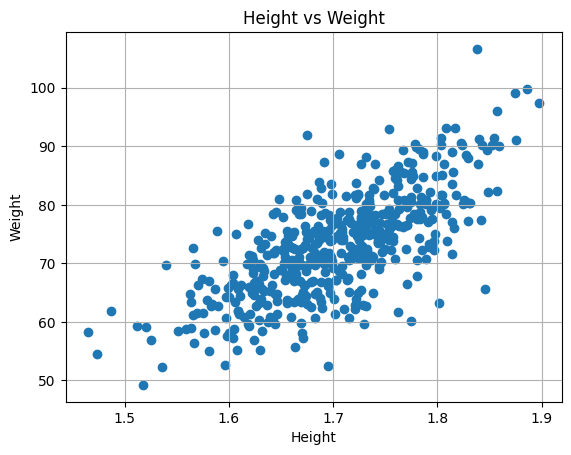

In [23]:
import matplotlib.pyplot as plt

height = data[:, 0]
weight = data[:, 1]

plt.scatter(height, weight)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.grid(True)
plt.show()

> **3.** To assess your colleague's claim, first create a box plot of the scores in task 1 and task 2. Also, compute the correlation between the two (using Pearson's $r$) and check whether it is significant. _Hint_: Use the function `scipy.stats.pearsonr`.

/tmp/ipykernel_894/4283447688.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([task1_score, task2_score], labels=['Task 1', 'Task 2'])


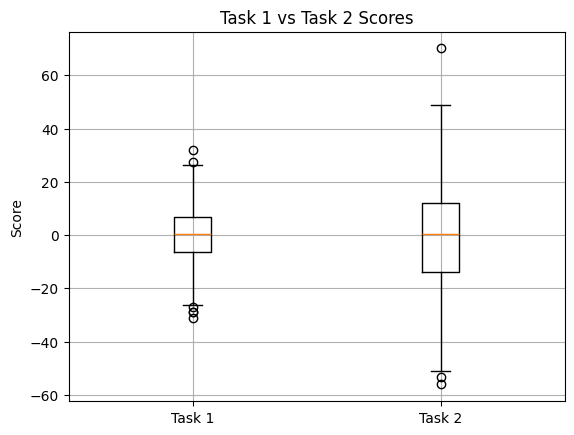

In [24]:
import matplotlib.pyplot as plt
from scipy import stats

task1_score = data[:, 3]
task2_score = data[:, 4]

# Box plot 그리기
plt.boxplot([task1_score, task2_score], labels=['Task 1', 'Task 2'])
plt.ylabel('Score')
plt.title('Task 1 vs Task 2 Scores')
plt.grid(True)
plt.show()

In [25]:
# 피어슨 상관계수 및 p-value 계산
## 상관계수가 0에 매우 가까우며, p-value가 기준치인 0.05보다 크므로 Task1과 Task2 성적 간의 상관관계는 통계적으로 유의미하지 않다.
r_value, p_value = stats.pearsonr(task1_score, task2_score)

print(f"Pearson's r: {r_value:.4f}")
print(f"p-value: {p_value:.4e}")

Pearson's r: 0.0804
p-value: 7.2357e-02


> **4.** When your colleague hears about your results, he is a bit disappointed. However, he already has a new hypothesis: maybe chocolate is acting as a promoter somehow and the amount of chocolate consumed has some effect? Create some plots and hypothesis tests to assess this new hypothesis.

In [29]:
# 변수 추출
choc = data[:, 2]
task1 = data[:, 3]
task2 = data[:, 4]

# 초콜릿 섭취량과 각 Task 점수의 상관관계 계산
## 초콜릿 섭취량과 두 과제 점수 간의 상관관계가 0에 가깝고, p-value가 0.05보다 훨씬 크므로,
## 초콜릿 섭취는 과제 수행 능력에 전혀 영향을 미치지 않는 것으로 결론 내릴 수 있다.
r1, p1 = stats.pearsonr(choc, task1)
r2, p2 = stats.pearsonr(choc, task2)

print(f"Chocolate vs Task 1: r = {r1:.4f}, p-value = {p1:.4e}")
print(f"Chocolate vs Task 2: r = {r2:.4f}, p-value = {p2:.4e}")

Chocolate vs Task 1: r = -0.0040, p-value = 9.2913e-01
Chocolate vs Task 2: r = -0.0026, p-value = 9.5362e-01


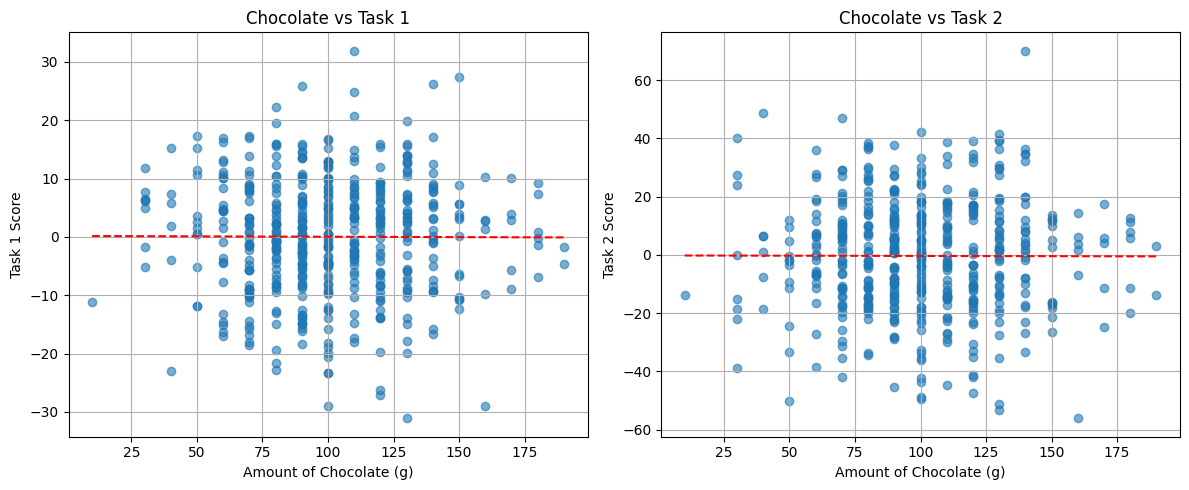

In [27]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chocolate vs Task 1
axes[0].scatter(choc, task1, alpha=0.6)
coefs1 = np.polyfit(choc, task1, 1)
axes[0].plot(np.unique(choc), np.poly1d(coefs1)(np.unique(choc)), 'r--')
axes[0].set_xlabel('Amount of Chocolate (g)')
axes[0].set_ylabel('Task 1 Score')
axes[0].set_title('Chocolate vs Task 1')
axes[0].grid(True)

# Chocolate vs Task 2
axes[1].scatter(choc, task2, alpha=0.6)
coefs2 = np.polyfit(choc, task2, 1)
axes[1].plot(np.unique(choc), np.poly1d(coefs2)(np.unique(choc)), 'r--')
axes[1].set_xlabel('Amount of Chocolate (g)')
axes[1].set_ylabel('Task 2 Score')
axes[1].set_title('Chocolate vs Task 2')
axes[1].grid(True)

plt.tight_layout()
plt.show()

> **5.** After you come back with your results, your colleague has one last idea: Maybe you need to eat more than some critical amount of chocolate (which depends on your body mass index) in order for there to be a correlation between the two tasks? He guesses that you need to eat at least six times your BMI in chocolate in order for the correlation to show up. You think your colleague is crazy, but go ahead an test his claim. What do you find? Again, produce some figures, compute correlations and test for significance.

In [30]:
height = data[:, 0]  # m단위
weight = data[:, 1]  # kg단위
choc = data[:, 2]    # g단위
task1 = data[:, 3]
task2 = data[:, 4]

# BMI 및 기준 초콜릿 양 계산
bmi = weight / (height ** 2)
threshold = 6 * bmi

In [31]:
# 초콜릿 섭취량 >= 6 * BMI을 만족하는 데이터 필터링
mask = choc >= threshold
filtered_task1 = task1[mask]
filtered_task2 = task2[mask]

# 필터링된 데이터의 상관계수 및 p-value 계산
r, p = stats.pearsonr(filtered_task1, filtered_task2)

print(f"Filtered count: {np.sum(mask)} / {len(data)}")
print(f"Task 1 vs Task 2 (Filtered): r = {r:.4f}, p-value = {p:.4e}")

Filtered count: 33 / 500
Task 1 vs Task 2 (Filtered): r = 0.9642, p-value = 1.9921e-19


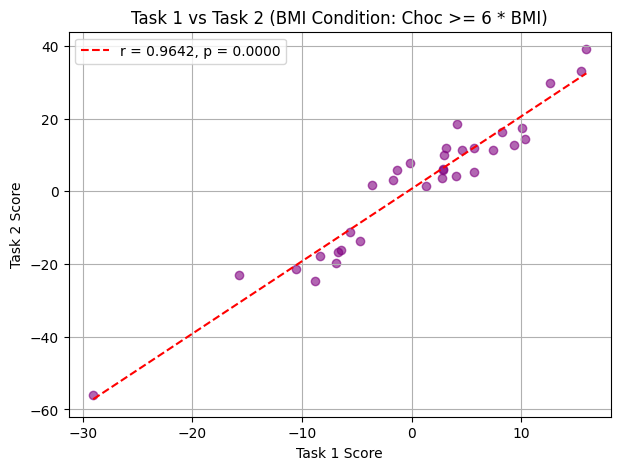

In [33]:
# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(filtered_task1, filtered_task2, alpha=0.6, color='purple')

coefs = np.polyfit(filtered_task1, filtered_task2, 1)
x_line = np.linspace(filtered_task1.min(), filtered_task1.max(), 100)
plt.plot(x_line, np.poly1d(coefs)(x_line), 'r--', label=f'r = {r:.4f}, p = {p:.4f}')

plt.xlabel('Task 1 Score')
plt.ylabel('Task 2 Score')
plt.title('Task 1 vs Task 2 (BMI Condition: Choc >= 6 * BMI)')
plt.legend()
plt.grid(True)
plt.show()

## BMI 대비 일정량 이상의 초콜릿을 섭취한 집단에서는 Task 1과 Task 2 점수 간에 매우 강한 양의 상관관계가 나타났으며, 이는 통계적으로 매우 유의미하다.
## 따라서 초콜릿을 특정 임계값 이상 섭취할 때 두 과제 수행 능력 간의 상관관계가 발현된다는 동료의 가설이 입증되었다.